<a href="https://colab.research.google.com/github/wajd-mq/wajd-mq/blob/main/RNN_vs_LSTM_vs_GRU3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("borismarjanovic/price-volume-data-for-all-us-stocks-etfs")

print("Path to dataset files:", path)

100%|██████████| 492M/492M [00:05<00:00, 92.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/borismarjanovic/price-volume-data-for-all-us-stocks-etfs/versions/3


In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

/content/sample_data/california_housing_test.csv
/content/sample_data/california_housing_train.csv
/content/sample_data/mnist_test.csv
/content/sample_data/mnist_train_small.csv


In [ ]:
import kagglehub
import os

# Download dataset
path = kagglehub.dataset_download(
    "borismarjanovic/price-volume-data-for-all-us-stocks-etfs"
)

print("Dataset path:")
print(path)


# عرض الملفات الموجودة
files = os.listdir(path)

print("\nNumber of files:", len(files))

print("\nFirst files:")
print(files[:10])

Using Colab cache for faster access to the 'price-volume-data-for-all-us-stocks-etfs' dataset.
Dataset path:
/kaggle/input/price-volume-data-for-all-us-stocks-etfs

Number of files: 3

First files:
['Stocks', 'ETFs', 'Data']


In [ ]:
import os

# مسار الأسهم
stocks_path = os.path.join(path, "Stocks")

# عرض الملفات
stock_files = os.listdir(stocks_path)

print("Number of stocks:", len(stock_files))

print(stock_files[:10])

Number of stocks: 7195
['ufi.us.txt', 'vfl.us.txt', 'sohu.us.txt', 'rdcm.us.txt', 'virt.us.txt', 'hylb.us.txt', 'skt.us.txt', 'asix.us.txt', 'mac.us.txt', 'gut.us.txt']


In [ ]:
import pandas as pd
import os

# اختيار سهم Apple
file_path = os.path.join(
    stocks_path,
    "aapl.us.txt"
)

df = pd.read_csv(file_path)

df.head()

,Date,Open,High,Low,Close,Volume,OpenInt
0,1984-09-07,0.42388,0.42902,0.41874,0.42388,23220030,0
1,1984-09-10,0.42388,0.42516,0.41366,0.42134,18022532,0
2,1984-09-11,0.42516,0.43668,0.42516,0.42902,42498199,0
3,1984-09-12,0.42902,0.43157,0.41618,0.41618,37125801,0
4,1984-09-13,0.43927,0.44052,0.43927,0.43927,57822062,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8364 entries, 0 to 8363
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     8364 non-null   object 
 1   Open     8364 non-null   float64
 2   High     8364 non-null   float64
 3   Low      8364 non-null   float64
 4   Close    8364 non-null   float64
 5   Volume   8364 non-null   int64  
 6   OpenInt  8364 non-null   int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 457.5+ KB


         Date     Open     High      Low    Close    Volume  OpenInt
0  1984-09-07  0.42388  0.42902  0.41874  0.42388  23220030        0
1  1984-09-10  0.42388  0.42516  0.41366  0.42134  18022532        0
2  1984-09-11  0.42516  0.43668  0.42516  0.42902  42498199        0
3  1984-09-12  0.42902  0.43157  0.41618  0.41618  37125801        0
4  1984-09-13  0.43927  0.44052  0.43927  0.43927  57822062        0

Shape:
(8364, 7)

Selected Data:
      Open     High      Low    Close    Volume
0  0.42388  0.42902  0.41874  0.42388  23220030
1  0.42388  0.42516  0.41366  0.42134  18022532
2  0.42516  0.43668  0.42516  0.42902  42498199
3  0.42902  0.43157  0.41618  0.41618  37125801
4  0.43927  0.44052  0.43927  0.43927  57822062


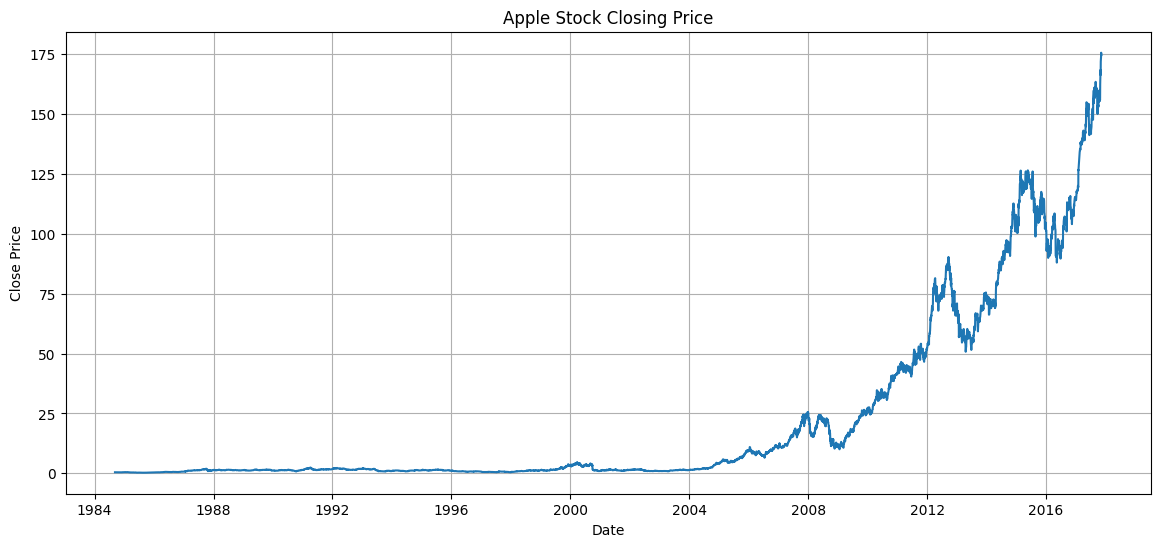

Scaled Shape: (8364, 5)

X Shape:
(8304, 60, 5)

y Shape:
(8304,)

Training:
(6643, 60, 5)
(6643,)

Testing:
(1661, 60, 5)
(1661,)


In [ ]:
# ==========================================
# Part 1: Data Preparation
# Stock Price Prediction
# RNN - LSTM - GRU
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler


# ==========================
# Load Stock Data
# ==========================

stock_name = "aapl.us.txt"

file_path = os.path.join(
    stocks_path,
    stock_name
)


df = pd.read_csv(file_path)


print(df.head())

print("\nShape:")
print(df.shape)



# ==========================
# Date Processing
# ==========================

df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values(
    'Date'
)



# ==========================
# Select Features
# ==========================

features = [
    'Open',
    'High',
    'Low',
    'Close',
    'Volume'
]


data = df[features]


print("\nSelected Data:")
print(data.head())



# ==========================
# Plot Close Price
# ==========================

plt.figure(figsize=(14,6))

plt.plot(
    df['Date'],
    df['Close']
)

plt.title(
    "Apple Stock Closing Price"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Close Price"
)

plt.grid()

plt.show()



# ==========================
# Scaling
# ==========================

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(
    data
)


print(
    "Scaled Shape:",
    scaled_data.shape
)



# ==========================
# Create Sequences
# ==========================

sequence_length = 60


X = []
y = []


for i in range(
    sequence_length,
    len(scaled_data)
):

    X.append(
        scaled_data[i-sequence_length:i]
    )

    # Close column index = 3
    y.append(
        scaled_data[i,3]
    )


X = np.array(X)

y = np.array(y)



print("\nX Shape:")
print(X.shape)


print("\ny Shape:")
print(y.shape)



# ==========================
# Train/Test Split
# ==========================

train_size = int(
    len(X)*0.8
)


X_train = X[:train_size]

X_test = X[train_size:]


y_train = y[:train_size]

y_test = y[train_size:]



print("\nTraining:")
print(X_train.shape)

print(y_train.shape)


print("\nTesting:")
print(X_test.shape)

print(y_test.shape)

In [ ]:
# =====================================================
# Part 2: Build and Train RNN, LSTM, GRU
# =====================================================

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    SimpleRNN,
    LSTM,
    GRU,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

import time


# ==========================
# Model Input Shape
# ==========================

input_shape = (
    X_train.shape[1],
    X_train.shape[2]
)


# ==========================
# Simple RNN
# ==========================

def build_rnn():

    model = Sequential()

    model.add(
        SimpleRNN(
            64,
            return_sequences=True,
            input_shape=input_shape
        )
    )

    model.add(
        Dropout(0.2)
    )


    model.add(
        SimpleRNN(64)
    )

    model.add(
        Dropout(0.2)
    )


    model.add(
        Dense(1)
    )


    model.compile(
        optimizer='adam',
        loss='mse'
    )


    return model



# ==========================
# LSTM
# ==========================

def build_lstm():

    model = Sequential()


    model.add(
        LSTM(
            64,
            return_sequences=True,
            input_shape=input_shape
        )
    )

    model.add(
        Dropout(0.2)
    )


    model.add(
        LSTM(64)
    )

    model.add(
        Dropout(0.2)
    )


    model.add(
        Dense(1)
    )


    model.compile(
        optimizer='adam',
        loss='mse'
    )


    return model



# ==========================
# GRU
# ==========================

def build_gru():

    model = Sequential()


    model.add(
        GRU(
            64,
            return_sequences=True,
            input_shape=input_shape
        )
    )


    model.add(
        Dropout(0.2)
    )


    model.add(
        GRU(64)
    )


    model.add(
        Dropout(0.2)
    )


    model.add(
        Dense(1)
    )


    model.compile(
        optimizer='adam',
        loss='mse'
    )


    return model



# ==========================
# Create Models
# ==========================

rnn_model = build_rnn()

lstm_model = build_lstm()

gru_model = build_gru()


print("RNN")
rnn_model.summary()


print("\nLSTM")
lstm_model.summary()


print("\nGRU")
gru_model.summary()



# ==========================
# Callbacks
# ==========================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)


reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=0.00001
)



# ==========================
# Training Function
# ==========================

def train_model(model, name):

    print("\n======================")
    print(name)
    print("======================")


    start = time.time()


    history = model.fit(
        X_train,
        y_train,
        epochs=50,
        batch_size=64,
        validation_split=0.1,
        callbacks=[
            early_stop,
            reduce_lr
        ],
        verbose=1
    )


    end = time.time()


    print(
        name,
        "Time:",
        round(end-start,2),
        "seconds"
    )


    return history, end-start



# ==========================
# Train Models
# ==========================


rnn_history, rnn_time = train_model(
    rnn_model,
    "Simple RNN"
)



lstm_history, lstm_time = train_model(
    lstm_model,
    "LSTM"
)



gru_history, gru_time = train_model(
    gru_model,
    "GRU"
)



print("\nTraining Finished")

RNN


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 60, 64)         │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,801 (50.00 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60, 64)         │        13,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,657 (151.00 KB)

 Trainable params: 38,657 (151.00 KB)

 Non-trainable params: 0 (0.00 B)


Simple RNN
Epoch 1/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.0143 - val_loss: 0.0013 - learning_rate: 0.0010
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0017 - val_loss: 3.2581e-04 - learning_rate: 0.0010
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 9.8732e-04 - val_loss: 6.1108e-04 - learning_rate: 0.0010
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 6.4735e-04 - val_loss: 5.0736e-04 - learning_rate: 0.0010
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 5.0868e-04 - val_loss: 2.8290e-04 - learning_rate: 0.0010
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 4.4474e-04 - val_loss: 3.0863e-04 - learning_rate: 5.0000e-04
Epoch 7/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 3.6549e-04 - val_loss: 5.5803e-04 - learning_rate: 5.0000e-04
Epoch 8/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 3.1866e-04 - val_loss: 2.3471e-04 - learning_rate: 5.0000e-04
Epoch 9/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step -

52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
Final Comparison


,Model,MSE,RMSE,MAE,R2 Score,Training Time
0,Simple RNN,343.812109,18.542171,15.099720,0.646175,41.694880
1,LSTM,52.548796,7.249055,5.273263,0.945921,85.385792
2,GRU,6.829618,2.613354,1.964951,0.992971,100.684326


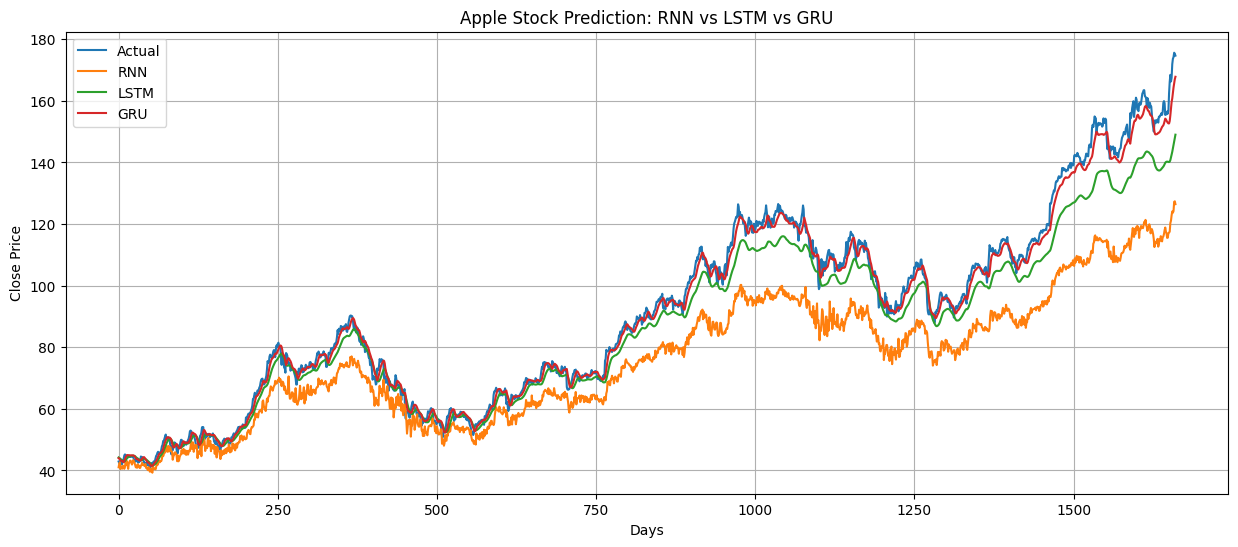

In [ ]:
# =====================================================
# Part 3: Prediction and Evaluation
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


# ==========================
# Prediction
# ==========================

rnn_pred = rnn_model.predict(X_test)

lstm_pred = lstm_model.predict(X_test)

gru_pred = gru_model.predict(X_test)



# ==========================
# Reverse Scaling
# ==========================
# لأننا نتوقع Close فقط
# نحتاج نرجع العمود الرابع


def inverse_close(pred):

    temp = np.zeros(
        (len(pred),5)
    )

    temp[:,3] = pred[:,0]

    return scaler.inverse_transform(temp)[:,3]



rnn_pred_real = inverse_close(
    rnn_pred
)

lstm_pred_real = inverse_close(
    lstm_pred
)

gru_pred_real = inverse_close(
    gru_pred
)



# True values

y_test_real = inverse_close(
    y_test.reshape(-1,1)
)



# ==========================
# Metrics Function
# ==========================

def calculate_metrics(y_true, y_pred):

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return mse, rmse, mae, r2



# ==========================
# Calculate
# ==========================

rnn_metrics = calculate_metrics(
    y_test_real,
    rnn_pred_real
)


lstm_metrics = calculate_metrics(
    y_test_real,
    lstm_pred_real
)


gru_metrics = calculate_metrics(
    y_test_real,
    gru_pred_real
)



# ==========================
# Results Table
# ==========================

results = pd.DataFrame({

    "Model":[
        "Simple RNN",
        "LSTM",
        "GRU"
    ],

    "MSE":[
        rnn_metrics[0],
        lstm_metrics[0],
        gru_metrics[0]
    ],

    "RMSE":[
        rnn_metrics[1],
        lstm_metrics[1],
        gru_metrics[1]
    ],

    "MAE":[
        rnn_metrics[2],
        lstm_metrics[2],
        gru_metrics[2]
    ],

    "R2 Score":[
        rnn_metrics[3],
        lstm_metrics[3],
        gru_metrics[3]
    ],

    "Training Time":[
        rnn_time,
        lstm_time,
        gru_time
    ]

})


print("========================")
print("Final Comparison")
print("========================")

display(results)



# ==========================
# Plot Comparison
# ==========================

plt.figure(figsize=(15,6))


plt.plot(
    y_test_real,
    label="Actual"
)


plt.plot(
    rnn_pred_real,
    label="RNN"
)


plt.plot(
    lstm_pred_real,
    label="LSTM"
)


plt.plot(
    gru_pred_real,
    label="GRU"
)


plt.title(
    "Apple Stock Prediction: RNN vs LSTM vs GRU"
)


plt.xlabel(
    "Days"
)


plt.ylabel(
    "Close Price"
)


plt.legend()

plt.grid()

plt.show()